----------

# **Classificação e NLP utilizando Spark**

Este script utiliza o Apache Spark para realizar classificação de texto em um conjunto de dados de avaliações do Yelp. O objetivo principal é classificar as avaliações como positivas (5 estrelas) ou negativas (menos de 5 estrelas).

As principais etapas realizadas são:

1.  **Obtenção e Análise Exploratória dos Dados**:
    *   Os dados são obtidos a partir de um arquivo JSON do Yelp.
    *   É feita uma análise inicial para entender a estrutura dos dados e a distribuição das estrelas nas avaliações.
    *   As avaliações de 5 estrelas são convertidas para o rótulo `1` (positivo) e as demais para `0` (negativo) para a classificação binária.

2.  **Pré-processamento do Texto (NLP)**:
    *   O texto das avaliações é tokenizado (dividido em palavras).
    *   Stopwords (palavras comuns como "e", "o", "a") são removidas para focar nas palavras mais relevantes.
    *   Duas técnicas de vetorização são aplicadas para converter o texto processado em representações numéricas que podem ser usadas por modelos de Machine Learning:
        *   **Bag of Words (BoW)** usando `HashingTF`.
        *   **Word2Vec** usando um modelo pré-treinado em português (`cbow_s50.txt`) para gerar embeddings vetoriais para as palavras e, em seguida, a média dos vetores para representar cada avaliação.

3.  **Treinamento e Teste de Modelos de Classificação**:
    *   Os dados são divididos em conjuntos de treino e teste.
    *   Dois modelos de classificação são treinados com as features geradas:
        *   Regressão Logística.
        *   Gradient-Boosted Tree (GBT).
    *   O desempenho dos modelos é avaliado usando a métrica Área sob a Curva ROC (AUC).

4.  **Comparação dos Modelos**:
    *   Os resultados de AUC dos dois modelos são comparados para determinar qual teve melhor desempenho na tarefa de classificação binária.

### dados Yelp Reviews

* Os dados que vamos utilizar é um conjunto de dados disponibilizado pela Yelp, contendo informações sobre avaliações de estabelecimentos como restaurantes, hotéis e lojas. Esse conjunto inclui dados como a avaliação, o texto da crítica, informações sobre o autor da avaliação, categoria do negócio, e muito mais. É amplamente utilizado para projetos de análise de sentimentos, classificação de texto e recomendação de negócios.


--------
# Importar bibliotecas

In [ ]:
# === Uso Geral ===
import os
import io
import requests

# === Manipulação de Dados ===
import pandas as pd
import numpy as np

# === Descompactadores ===
import tarfile
import zipfile

# === Visualização ===
import plotly.express as px

# === Spark Core ===
from pyspark.sql import SparkSession

# === Spark SQL Functions ===
from pyspark.sql.functions import (
    when, col,
    length, split, size,
    avg, sum as _sum,
    hour, to_timestamp
)

# === Spark ML - Feature Engineering ===
from pyspark.ml.feature import (
    Tokenizer,
    StopWordsRemover,
    StringIndexer,
    HashingTF,
    VectorAssembler,
    MinMaxScaler
)

from pyspark.sql.functions import udtf
from pyspark.ml.linalg import Vectors, VectorUDT

# === Spark ML - Classificação ===
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
    GBTClassifier,
    NaiveBayes
)

# === Spark ML - Pipeline e Tuning ===
from pyspark.ml import Pipeline
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder
from pyspark.sql.functions import udf
from pyspark.ml.linalg import VectorUDT
from pyspark.ml.linalg import Vectors

# === Spark ML - Avaliação ===
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)


----------

### Obtenção dos dados e análise exploratória

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Criando uma sessão Spark
spark = SparkSession.builder \
    .appName("Yelp Dataset") \
    .getOrCreate()

------------
### Baixe os dados (JSON)

https://business.yelp.com/data/resources/open-dataset/


In [ ]:
#-----------------------------------------------------
### Diretórios
zip_path = '/content/yelp.zip'
extract_path = '/content/yelp'

#-----------------------------------------------------
### Download do arquivo ZIP
url = 'https://business.yelp.com/external-assets/files/Yelp-JSON.zip'
headers = {'User-Agent': 'Mozilla/5.0'}

r = requests.get(url, headers=headers, stream=True)
if r.status_code == 200:
    with open(zip_path, 'wb') as f:
        for chunk in r.iter_content(1024):
            f.write(chunk)
    print("Download completo.")
else:
    raise Exception(f"Erro no download: {r.status_code}")

#----------------------------------------------------
### Extração do ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extração concluída.")

# Caminho do JSON (ajuste conforme nome exato após extração)
json_path = '/content/yelp/Yelp JSON/yelp_academic_dataset_review.json'

#-----------------------------------------------------
### EXTRATIR .TAR
tar_path = '/content/yelp/Yelp JSON/yelp_dataset.tar'

# Extração do TAR
with tarfile.open(tar_path, 'r') as tar_ref:
    tar_ref.extractall(extract_path)
print("TAR extraído.")

# Verifica o conteúdo
!ls "$extract_path"

# Caminhos dos JSONs
json_path_review = '/content/yelp/yelp_academic_dataset_review.json'
json_path_business = '/content/yelp/yelp_academic_dataset_business.json'
json_path_checkin = '/content/yelp/yelp_academic_dataset_checkin.json'
json_path_tip = '/content/yelp/yelp_academic_dataset_tip.json'
json_path_user = '/content/yelp/yelp_academic_dataset_user.json'


---------
### Prévia das tabelas disponíveis

In [ ]:
# Leitura
df_review = spark.read.json(json_path_review)
df_business = spark.read.json(json_path_business)
df_checkin = spark.read.json(json_path_checkin)
df_tip = spark.read.json(json_path_tip)
df_user = spark.read.json(json_path_user)

# Prévia de cada DataFrame
print("Review:")
df_review.show(3, truncate=False)

print("\nBusiness:")
df_business.show(3, truncate=False)

print("\nCheckin:")
df_checkin.show(3, truncate=False)

print("\nTip:")
df_tip.show(3, truncate=False)

print("\nUser:")
df_user.show(3, truncate=False)


---------

### Vamos trabalhar com os dados de Reviews

**Dicionário**
| Coluna            | Tipo       | Descrição |
|--------------------|------------|------------|
| review_id          | string     | Identificador único da avaliação. |
| user_id            | string     | Identificador do usuário que fez a avaliação. |
| business_id        | string     | Identificador do estabelecimento avaliado. |
| stars              | integer    | Classificação atribuída pelo usuário (1 a 5 estrelas). |
| useful             | integer    | Número de votos indicando que a avaliação foi útil. |
| funny              | integer    | Número de votos indicando que a avaliação foi engraçada. |
| cool               | integer    | Número de votos indicando que a avaliação foi "legal". |
| text               | string     | Texto completo da avaliação escrita pelo usuário. |
| date               | string     | Data em que a avaliação foi publicada (formato YYYY-MM-DD). |

In [ ]:
# Ler o arquivo JSON para um DataFrame
df = spark.read.json(json_path_review)

## Exibir dataset
df.show(10)

In [ ]:
## Exibir schema
df.printSchema()

In [ ]:
# Selecionando colunas que vamos utilizar
df.select(['text', 'stars']).show(10, truncate=False)

In [ ]:
# Criar dataframe com as colunas de interesse
df_reviews = df.select('text', 'stars')

### Checkpoint 1

In [ ]:
#----------------------------
### Salvar
#----------------------------

# Salvar o DataFrame em formato Parquet (local)
df_reviews.write.mode('overwrite').parquet('reviews')

# Salvar o DataFrame em formato Parquet (google driver)
output_path = '/content/drive/MyDrive/spark/reviews'
df_review.write.mode('overwrite').parquet(output_path)


In [ ]:
#----------------------------
### Importar
#----------------------------
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Criando uma sessão Spark
spark = SparkSession.builder \
    .appName("Yelp Dataset") \
    .getOrCreate()

# importar dataframe salvo no google driver
output_path = '/content/drive/MyDrive/spark/reviews'
df_reviews = spark.read.parquet(output_path)

# Verificar os dados
df_reviews.show(5)

+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+
|         business_id|cool|               date|funny|           review_id|stars|                text|useful|             user_id|
+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+
|znK6tMeegKf9YnGut...|   0|2021-04-16 22:02:21|    0|MmmrqbdupYBJq9jnl...|  5.0|Great little spot...|     0|TjD2S66AWxlKsPSQB...|
|UxwpCVLgPWCeaRyet...|   0|2021-01-03 21:54:48|    0|1_uWX0bBJNnZjPEcp...|  5.0|James was super k...|     0|Vtfxxq3nxdYHRiH6O...|
|eVI64EQymywsvMLmD...|   0|2020-11-01 19:50:03|    0|WVAEE47MnM3Sv2cvM...|  5.0|By far the best i...|     0|ZDw_qN5Fy6PE0gdbV...|
|SPcPJfPgWzhjUDqVF...|   0|2021-03-24 05:53:49|    0|D5b6iooZZcJ8nG-9P...|  5.0|I thought that th...|     0|UvMDlX2wV4Md9OwGW...|
|T5XzQ6YnVExvd0BOR...|   0|2016-06-13 21:25:10|    0|uDxnT7zWFnxEDxp5e...|  5.0|Aside from

In [ ]:
# Contar número de reviews (linhas)
df_reviews.count()

6990280

### Group by com Spark

O código abaixo realiza uma agregação na coluna "stars" do DataFrame df_review:

1. groupBy("stars"): agrupa as linhas pelo valor da coluna "stars".

2. count(): conta quantas linhas existem em cada grupo de "stars".

3. withColumnRenamed("count", "no_of_rows"): renomeia a coluna "count" para "no_of_rows".

4. orderBy("stars"): ordena o resultado final de acordo com os valores de "stars".

O resultado é um novo DataFrame (df_stars) que mostra, para cada valor de "stars".


In [ ]:
# Agregação no Spark
df_stars = (
    df_reviews.groupBy("stars")
    .count()
    .withColumnRenamed("count", "no_of_rows")
    .orderBy("stars")
)

# Converter para Pandas (necessário para o Plotly)
pdf_stars = df_stars.toPandas()

# Calcular porcentagem
pdf_stars["percent"] = (pdf_stars["no_of_rows"] / pdf_stars["no_of_rows"].sum()) * 100

# Plot com Plotly
fig = px.bar(
    pdf_stars,
    x="stars",
    y="no_of_rows",
    title="Distribuição de Avaliações por Estrelas",
    labels={"stars": "Estrelas", "no_of_rows": "Número de Avaliações"},
    text=pdf_stars["percent"].apply(lambda x: f"{x:.1f}%")  # exibe porcentagem formatada
)

fig.update_traces(textposition="outside")

fig.update_layout(
    template="plotly_white",
    xaxis=dict(dtick=1),
    title_x=0.5,
    yaxis_title="Número de Avaliações (%)"
)

fig.show()



In [ ]:
# Criar coluna com contagem de palavras
df_reviews = df_reviews.withColumn("word_count", size(split(df_reviews["text"], " ")))

# Criar coluna com contagem de caracteres
df_reviews = df_reviews.withColumn("char_count", length(df_reviews["text"]))

# Calcular média de palavras e caracteres por estrelas
df_stats = (
    df_reviews.groupBy("stars")
    .agg(
        avg("word_count").alias("media_palavras"),
        avg("char_count").alias("media_caracteres")
    )
    .orderBy("stars")
)

# Converter para Pandas para plotar
pdf_stats = df_stats.toPandas()

# Plot duplo — comparando médias
fig = px.bar(
    pdf_stats.melt(id_vars="stars", value_vars=["media_palavras", "media_caracteres"],
                   var_name="Métrica", value_name="Média"),
    x="stars",
    y="Média",
    color="Métrica",
    barmode="group",
    text_auto=".1f",
    title="Média de Palavras e Caracteres por Avaliação (Stars)",
    labels={"stars": "Estrelas", "Média": "Média"}
)

fig.update_layout(template="plotly_white", title_x=0.5, xaxis=dict(dtick=1))

fig.show()


**Interpretação:**

Tendência clara: quanto maior a nota, menor o texto do review.

Reviews negativos (1–2 estrelas) são mais longos — geralmente os usuários detalham mais suas insatisfações.

Reviews positivos (5 estrelas) são mais curtos e diretos, com frases simples como “Excelente!”, “Amei!”, “Perfeito!”.

Essa diferença no comprimento do texto pode servir como uma feature preditiva útil — modelos podem aprender que textos curtos têm maior probabilidade de serem positivos.

Resumo:                          
O total e a média de palavras confirmam um padrão comportamental comum: insatisfações são mais explicadas; satisfações, mais objetivas.

In [ ]:
# Verificando se há valores vazios ou NaN em 'df_reviews'
df_reviews.filter(df_reviews['text'].isNull() | (df_reviews['text'] == '') | df_reviews['stars'].isNull()).show()


+-----------+----+----+-----+---------+-----+----+------+-------+----------+----------+
|business_id|cool|date|funny|review_id|stars|text|useful|user_id|word_count|char_count|
+-----------+----+----+-----+---------+-----+----+------+-------+----------+----------+
+-----------+----+----+-----+---------+-----+----+------+-------+----------+----------+



### Abordagem metodológica

Embora o problema seja originalmente de classificação multiclasse, para fins de exercício será tratado como uma classificação binária. O foco será identificar e prever as avaliações mais positivas, ou seja, aquelas com cinco estrelas, em contraste com as demais.

In [ ]:
# Gerar Dummy, substituindo os valores de 'stars' para 1 ou 0, diretamente na coluna
df_reviews = df_reviews.withColumn(
    "stars",
    when(df_reviews["stars"] == 5, 1).otherwise(0)
)

# Agregação no Spark
df_stars = (
    df_reviews.groupBy("stars")
    .count()
    .withColumnRenamed("count", "no_of_rows")
    .orderBy("stars")
)

# Converter para Pandas (necessário para Plotly)
pdf_stars = df_stars.toPandas()

# Gráfico de pizza com Plotly
fig = px.pie(
    pdf_stars,
    names="stars",
    values="no_of_rows",
    title="Distribuição de Avaliações por Estrelas",
    hole=0.3
)

fig.update_traces(textinfo="percent+label")

fig.update_layout(template="plotly_white", title_x=0.5)

fig.show()


**Interpretação**

* 0 → avaliações de 1 a 4 estrelas

* 1 → avaliações de 5 estrelas

Com essa transformação, as classes ficam mais equilibradas em termos de quantidade de registros, o que é desejável em problemas de classificação. Esse balanceamento reduz o risco de o modelo se tornar tendencioso para uma classe majoritária, permitindo uma melhor capacidade de generalização e desempenho mais estável nas previsões.


-------------

## NLP (Processamento de Linguagem Natural)

Nesta seção, será aplicada Processamento de Linguagem Natural (NLP) com o objetivo de construir um modelo preditivo capaz de identificar avaliações de cinco estrelas a partir do texto dos reviews.

----------
### Etapas do pipeline:
### Explicação do Pipeline NLP

Esse fluxo cria uma **pipeline de pré-processamento de texto** em Spark para preparar os dados antes de treinar um modelo de classificação binária (reviews 5 estrelas vs. demais).

**Etapas principais:**

1. **Seleção e transformação de colunas**
   - Mantém apenas `text` e `stars`.
   - Converte `stars` em binária:  
     `1` → 5 estrelas (review positivo)  
     `0` → demais.

2. **Amostragem**
   - Usa apenas **10% dos dados** (`fraction=0.1`) para reduzir tempo de processamento.

3. **Indexação**
   - Transforma `stars` em `label` numérica para o modelo entender como variável-alvo.
    Exigência do Spark ML: Algoritmos de classificação esperam a variável-alvo como tipo numérico (Double) na coluna label.
    Mapeamento: Transforma stars (String/Int) → label (0.0 ou 1.0).
    Metadata: Adiciona informações sobre as classes (0 = negativo, 1 = positivo) que alguns modelos usam internamente.

4. **Tokenização**
   - Divide o texto em Tokens (`Tokenizer`).
    Texto → Tokens: Divide string contínua em lista de palavras individuais.
    Exemplo: "Great food!" → ["Great", "food", "!"]
    Granularidade: Permite análise no nível de palavra (unidade básica de significado).
    Normalização básica: Converte para lowercase automaticamente ("Great" → "great"), reduzindo variabilidade.

5. **Remoção de stopwords**
   - Elimina palavras sem valor semântico (como “de”, “a”, “o”).
    Ruído semântico: Palavras como "de", "a", "o", "que" ocorrem com alta frequência mas não distinguem sentimento positivo/negativo.
    Redução de dimensionalidade: Elimina ~30-40% dos tokens, diminuindo o vetor de features sem perda de informação relevante.
    Foco em conteúdo: Mantém apenas substantivos, adjetivos, verbos que carregam sentimento ("excelente", "péssimo", "adorei").
    Lista pré-definida: Spark usa stopwords padrão do inglês (já que reviews Yelp são em inglês).

6. **Vetorização (Bag of Words)**
    - Converte o texto em vetores numéricos (`HashingTF`) com 50 features. O BoW (Bag of Words) é uma técnica de extração de características que cria uma representação vetorial de um documento com base nas palavras presentes nele, sem considerar a ordem das palavras.                    
    Aplica função hash em cada palavra e mapeia para uma das 50 posições do vetor.
    * Vantagem: Não precisa construir vocabulário explícito (economiza memória, funciona com palavras desconhecidas).
    * Desvantagem: Colisões — palavras diferentes podem cair no mesmo índice (aceitável com numFeatures adequado).
    * numFeatures=50:                           
    
    Compromisso entre precisão e eficiência:
    - Muito baixo (10): muitas colisões, perde informação.
    - Muito alto (10.000): overfitting, processamento lento.
    - 50: suficiente para capturar padrões básicos em dataset amostrado.
                                      
    Saída (rawFeatures):                            
    * Vetor esparso de 50 dimensões: [0, 3, 0, 1, 0, ..., 2]
    Cada posição = soma das ocorrências de palavras que foram "hashadas" para aquele índice.
    * Alternativa (não usada aqui): CountVectorizer cria vocabulário explícito mas consome mais memória.

7. **Pipeline**
   - Une todas as etapas e aplica de forma sequencial nos dados.                               

    **Objetivo:**  
    - Gerar um DataFrame transformado (`featurizedData`) com as colunas:
    - `filtered`: lista de tokens limpos.  
    - `rawFeatures`: representação numérica do texto.  

    Esses vetores serão usados depois para **treinar um modelo de classificação de sentimento (5 estrelas)**.

Em resumo: pegamos texto cru, limpamos e transformamos em números — o formato necessário para treinar um modelo de machine learning.

 --------------
### Acesse a documentação da MLLib para mais detalhes
[MLLib Documentation](https://spark.apache.org/docs/3.5.4/ml-guide.html)

In [ ]:
### PIPELINE com uma amostragem aleatória de 10%

# Pegando uma amostra aleatória de n linhas para teste (substitua n pelo valor desejado)
df_reviews = df_reviews.sample(withReplacement=False, fraction=1.00)  # Exemplo: 100% dos dados

# Converter a coluna "stars" em uma coluna numérica "label" para a classificação
indexer = StringIndexer(inputCol="stars", outputCol="label")

df_reviews = indexer.fit(df_reviews).transform(df_reviews)

# Tokenização
tokenizer = Tokenizer(inputCol="text", outputCol="words")

# Remoção de Stopwords
remover = StopWordsRemover(inputCol="words", outputCol="filtered")

# Vetorização Bag of Words
hashingTF = HashingTF(inputCol="filtered", outputCol="rawFeatures", numFeatures=50)

# Definição do pipeline
pipeline = Pipeline(stages=[tokenizer, remover, hashingTF])

# Aplicação do pipeline
model = pipeline.fit(df_reviews)
featurizedData = model.transform(df_reviews)

# Exibir resultados
featurizedData.select("stars").show(5, truncate=False)
featurizedData.select("filtered").show(5, truncate=False)
featurizedData.select("rawFeatures").show(5, truncate=False)

+-----+
|stars|
+-----+
|1    |
|1    |
|1    |
|1    |
|1    |
+-----+
only showing top 5 rows

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|filtered                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [ ]:
featurizedData.columns

['business_id',
 'cool',
 'date',
 'funny',
 'review_id',
 'stars',
 'text',
 'useful',
 'user_id',
 'word_count',
 'char_count',
 'label',
 'words',
 'filtered',
 'rawFeatures']

In [ ]:
# Selecionar colunas
df_ml = featurizedData.select("label", "word_count", "char_count", "rawFeatures")

# Exibir as primeiras linhas
df_ml.show(5, truncate=False)

+-----+----------+----------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|word_count|char_count|rawFeatures                                                                                                                                                                                                                             |
+-----+----------+----------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|1.0  |59        |326       |(50,[0,2,4,8,10,11,13,14,18,20,21,23,25,26,29,30,33,35,39,40,43,45,46,48],[3.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0])          

In [ ]:
#--------------------------
### Salvar
#--------------------------
# Caminho base no Google Drive
base_path = "/content/drive/MyDrive/spark"

# 1. Salvar a amostra (df_tune)
df_tune.write.mode("overwrite").parquet(f"{base_path}/df_tune")

# 2. Salvar treino e teste
train_data.write.mode("overwrite").parquet(f"{base_path}/train_data")
test_data.write.mode("overwrite").parquet(f"{base_path}/test_data")

# 3. (Opcional) Salvar o DataFrame original df_reviews
df_reviews.write.mode("overwrite").parquet(f"{base_path}/df_reviews")

------------------
------------------
# **Classificação**

## **Treinamento e teste**

### Funções auxiliares para facilitar a comparação dos modelos, já que não vamos utilizar o mlflow

### Amostragem Estratificada no Spark

Como este é um exercício, utilizaremos uma abordagem de **Amostragem Estratificada** em vez de **Cross-Validation**, que seria muito pesado para um dataset com **7 milhões de linhas**.

Quando há **duas classes desbalanceadas** (por exemplo, `label = 0` com 70% e `label = 1` com 30%), uma amostra aleatória simples pode selecionar muito mais registros de uma classe do que da outra, distorcendo a distribuição original.

A função `.sampleBy(col, fractions)` permite **manter a proporção de cada classe** na amostra, garantindo representatividade.

### Checkpoint 2

In [ ]:
#--------------------------
### Importar
#--------------------------
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Criando uma sessão Spark
spark = SparkSession.builder \
    .appName("Yelp Dataset") \
    .getOrCreate()

# Caminho base
base_path = "/content/drive/MyDrive/spark"

# Importar DataFrames
df_tune = spark.read.parquet(f"{base_path}/df_tune")
train_data = spark.read.parquet(f"{base_path}/train_data")
test_data = spark.read.parquet(f"{base_path}/test_data")
df_reviews = spark.read.parquet(f"{base_path}/df_reviews")

# Verificar
df_tune.show(5)
train_data.printSchema()

Mounted at /content/drive
+-----+----------+----------+--------------------+
|label|word_count|char_count|         rawFeatures|
+-----+----------+----------+--------------------+
|  1.0|        65|       348|(50,[0,2,3,8,10,1...|
|  1.0|        70|       353|(50,[1,2,4,5,6,8,...|
|  1.0|       206|      1120|(50,[0,2,3,4,6,7,...|
|  1.0|        68|       423|(50,[0,2,3,4,6,7,...|
|  1.0|        23|       105|(50,[8,14,15,16,2...|
+-----+----------+----------+--------------------+
only showing top 5 rows

root
 |-- label: double (nullable = true)
 |-- word_count: integer (nullable = true)
 |-- char_count: integer (nullable = true)
 |-- rawFeatures: vector (nullable = true)



In [ ]:
# Utilitário: treina, avalia e registra métricas para comparação entre modelos

#  1) Amostragem estratificada
fractions = {0: 0.10, 1: 0.10}
df_tune = df_ml.sampleBy("label", fractions, seed=42)

# 2) Split
train_data, test_data = df_tune.randomSplit([0.8, 0.2], seed=1234)

# 3) Numéricas -> vetor temporário
assembler_num = VectorAssembler(
    inputCols=["word_count", "char_count"],
    outputCol="num_features"
)

# 4) Escalonar 0–1
scaler = MinMaxScaler(inputCol="num_features", outputCol="scaled_features")

# 5) Concatenar texto + numéricas escaladas
assembler_final = VectorAssembler(
    inputCols=["rawFeatures", "scaled_features"],
    outputCol="final_features"
)

# Avaliadores
e_auc_roc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
e_auc_pr  = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderPR")
e_f1      = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
e_acc     = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
e_prec    = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedPrecision")
e_rec     = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedRecall")

results = []

def eval_and_log(model, name: str):
    pipeline = Pipeline(stages=[assembler_num, scaler, assembler_final, model])
    fitted = pipeline.fit(train_data)
    preds = fitted.transform(test_data)
    row = {
        "modelo": name,
        "AUC_ROC": float(e_auc_roc.evaluate(preds)),
        "AUC_PR":  float(e_auc_pr.evaluate(preds)),
        "F1":      float(e_f1.evaluate(preds)),
        "Acc":     float(e_acc.evaluate(preds)),
        "Prec":    float(e_prec.evaluate(preds)),
        "Rec":     float(e_rec.evaluate(preds)),
    }
    results.append(row)
    return preds



## **Logistic Regression**




In [ ]:
### Logistic Regression
# Definição do modelo
lr = LogisticRegression(
    featuresCol="final_features",
    labelCol="label",
    regParam=0.1,
    elasticNetParam=0.5,
    maxIter=50
)
_ = eval_and_log(lr, "LogisticRegression")

# Tabela final (pandas)
df_metrics = (
    pd.DataFrame(results)
    .sort_values(by="AUC_ROC", ascending=False)
    .reset_index(drop=True)
)

df_metrics

# Opcional: salvar
# df_metrics.to_csv("metricas_modelos.csv", index=False)

,modelo,AUC_ROC,AUC_PR,F1,Acc,Prec,Rec
0,LogisticRegression,0.632789,0.5711,0.439932,0.552144,0.58797,0.552144


### **Gradient-Boosted Tree Classifier (GBTs)**

In [ ]:
# GBTClassifier
gbt = GBTClassifier(
    featuresCol="final_features",
    labelCol="label",
    maxIter=50,      # nº de árvores (iterações de boosting)
    maxDepth=5,
    stepSize=0.1
)
_ = eval_and_log(gbt, "GBTClassifier")

# Tabela final (pandas)
df_metrics = (
    pd.DataFrame(results)
    .sort_values(by="AUC_ROC", ascending=False)
    .reset_index(drop=True)
)

df_metrics

# Opcional: salvar
# df_metrics.to_csv("metricas_modelos.csv", index=False)


,modelo,AUC_ROC,AUC_PR,F1,Acc,Prec,Rec
0,GBTClassifier,0.680956,0.640281,0.629916,0.632923,0.63160,0.632923
1,LogisticRegression,0.632789,0.571100,0.439932,0.552144,0.58797,0.552144


### **Random Forest Classifier**

In [ ]:
# RandomForestClassifier
rf = RandomForestClassifier(
    featuresCol="final_features",
    labelCol="label",
    numTrees=100,
    maxDepth=10,
    subsamplingRate=0.8,
    featureSubsetStrategy="auto"
)
_ = eval_and_log(rf, "RandomForestClassifier")

# Tabela final (pandas)
df_metrics = (
    pd.DataFrame(results)
    .sort_values(by="AUC_ROC", ascending=False)
    .reset_index(drop=True)
)

df_metrics

# Opcional: salvar
# df_metrics.to_csv("metricas_modelos.csv", index=False)

,modelo,AUC_ROC,AUC_PR,F1,Acc,Prec,Rec
0,GBTClassifier,0.680956,0.640281,0.629916,0.632923,0.631600,0.632923
1,RandomForestClassifier,0.662271,0.621707,0.617630,0.620302,0.618677,0.620302
2,LogisticRegression,0.632789,0.571100,0.439932,0.552144,0.587970,0.552144


### **Naive Bayes Classifier**

In [ ]:
# ===== NaiveBayes =====
nb = NaiveBayes(
    featuresCol="features",
    labelCol="label",
    modelType="multinomial",
    smoothing=1.0
)
_ = eval_and_log(nb, "NaiveBayes")

# Tabela final (pandas)
df_metrics = (
    pd.DataFrame(results)
    .sort_values(by="AUC_ROC", ascending=False)
    .reset_index(drop=True)
)

df_metrics

# Opcional: salvar
# df_metrics.to_csv("metricas_modelos.csv", index=False)

,modelo,AUC_ROC,AUC_PR,F1,Acc,Prec,Rec
0,GBTClassifier,0.680956,0.640281,0.629916,0.632923,0.631600,0.632923
1,RandomForestClassifier,0.662271,0.621707,0.617630,0.620302,0.618677,0.620302
2,LogisticRegression,0.632789,0.571100,0.439932,0.552144,0.587970,0.552144
3,NaiveBayes,0.619843,0.555618,0.593411,0.597301,0.595036,0.597301


#------------------------------

## **Modelos pré-treinados**

**GloVe (Global Vectors for Word Representation)**

https://nlp.stanford.edu/projects/glove/

O que é GloVe?GloVe? é um algoritmo de aprendizado não-supervisionado desenvolvido por Stanford em 2014 que cria representações vetoriais densas de palavras capturando relações semânticas e sintáticas entre elas.Princípio Fundamental Diferente de métodos que olham apenas contexto local (janela de palavras), GloVe combina:

* Estatísticas globais: Analisa todo o corpus para entender co-ocorrências
* Álgebra linear: Fatoriza a matriz de co-ocorrência
* palavra-palavra

### Como Funciona?

### 1. Construção da Matriz de Co-ocorrência
- Conta quantas vezes a palavra `i` aparece perto da palavra `j` em todo o corpus
- Considera janela de contexto (ex: 5 palavras antes/depois)

### 2. Otimização
- Treina vetores para que o produto escalar entre dois vetores seja próximo do logaritmo da probabilidade de co-ocorrência
- Fórmula: `vetor(palavra_i) · vetor(palavra_j) ≈ log(P(i,j))`

### 3. Resultado
- Cada palavra vira um vetor denso de 50-300 dimensões
- Palavras semanticamente similares têm vetores próximos no espaço vetorial

---

### GloVe vs Bag of Words

| Característica | Bag of Words (BoW) | GloVe |
|----------------|-------------------|-------|
| **Tipo de vetor** | Esparso (99% zeros) | Denso (todos valores preenchidos) |
| **Dimensões** | 5.000 - 50.000 (tamanho do vocabulário) | 50 - 300 (fixo) |
| **Memória** | Alta (milhares de colunas) | Baixa (centenas de colunas) |
| **Semântica** | Zero ("bom" ≠ "ótimo") | Preservada ("bom" ≈ "ótimo") |
| **Relações** | Não captura | Captura ("rei" - "homem" + "mulher" ≈ "rainha") |
| **Contexto** | Ignora ordem/vizinhança | Aprende de co-ocorrências |
| **Treinamento** | Nenhum (apenas contagem) | Pré-treinado em bilhões de palavras |
| **Palavras novas** | Funciona (cria nova coluna) | Problema (usa vetor zero) |

---

## Vantagens do GloVe

### 1. **Captura Semântica Real**
```
BoW:
"comida excelente" → [0, 1, 0, 0, 1, 0, ...]
"comida ótima"     → [0, 1, 0, 1, 0, 0, ...]
                      ↑ vetores completamente diferentes

GloVe:
"comida excelente" → [0.23, 0.81, -0.42, ...]
"comida ótima"     → [0.21, 0.79, -0.39, ...]
                      ↑ vetores similares (distância cosseno ≈ 0.95)
```

### 2. **Redução Drástica de Dimensionalidade**
- **BoW:** 50.000 features (vocabulário Yelp) → modelo pesado, overfitting
- **GloVe:** 100 features fixas → modelo leve, generaliza melhor

### 3. **Conhecimento Externo Gratuito**
- Embeddings pré-treinados em Wikipedia (6 bilhões de tokens)
- Não precisa de milhões de dados para aprender "rei ≈ monarca"
- Transfer learning: conhecimento de um corpus gigante aplicado ao seu problema

### 4. **Robustez a Sinônimos**
```
Review: "serviço horrível"
Review: "atendimento péssimo"

BoW: Trata como textos completamente diferentes
GloVe: Identifica similaridade semântica (ambos negativos)

### 5. Menos Overfitting

* BoW memoriza palavras específicas do treino
* GloVe generaliza conceitos (aprende "sentimento negativo" vs palavras isoladas)

### Conclusão
* GloVe supera BoW em praticamente todos os aspectos para NLP moderno:

* Menor dimensionalidade = modelos mais eficientes
* Semântica preservada = melhor acurácia
* Transfer learning = aproveita conhecimento externo

Para classificação de sentimento em reviews do Yelp, GloVe é a escolha natural que equilibra performance e simplicidade.

In [ ]:
# 1. Download do glove 100 dimenssões e extração
!wget -O glove_s100.zip "https://nlp.stanford.edu/data/wordvecs/glove.2024.wikigiga.100d.zip"
!unzip glove_s100.zip -d glove_embeddings
!ls -lh glove_embeddings/

# 2. Carregar embeddings
VECTOR_SIZE = 100
glove_embeddings = {}

glove_path = '/content/glove_embeddings/wiki_giga_2024_100_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05.050_combined.txt'

with open(glove_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        try:
            values = line.strip().split()
            if len(values) > VECTOR_SIZE:
                word = values[0]
                vector = np.array(values[1:VECTOR_SIZE+1], dtype='float32')
                glove_embeddings[word] = vector
        except:
            continue

        if i % 100000 == 0:
            print(f"Processadas {i} linhas...")

print(f"\nGloVe carregado: {len(glove_embeddings)} palavras")
print(f"Primeiras palavras: {list(glove_embeddings.keys())[:10]}")

--2025-10-23 22:52:34--  https://nlp.stanford.edu/data/wordvecs/glove.2024.wikigiga.100d.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/wordvecs/glove.2024.wikigiga.100d.zip [following]
--2025-10-23 22:52:35--  https://downloads.cs.stanford.edu/nlp/data/wordvecs/glove.2024.wikigiga.100d.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 581925049 (555M) [application/zip]
Saving to: ‘glove_s100.zip’

glove_s100.zip      100%[===================>] 554.97M  5.02MB/s    in 1m 45s  

2025-10-23 22:54:21 (5.26 MB/s) - ‘glove_s100.zip’ saved [581925049/581925049]

Archive:  glove_s100.zip
  inf

In [ ]:

def tokens_to_glove_vec(tokens):
    if not tokens:
        return Vectors.dense([0.0] * VECTOR_SIZE)

    vectors = []
    for word in tokens:
        if word in glove_embeddings:
            vec = glove_embeddings[word]
            if len(vec) == VECTOR_SIZE:
                vectors.append(vec)

    if not vectors:
        return Vectors.dense([0.0] * VECTOR_SIZE)

    mean_vector = np.array(vectors).mean(axis=0)
    return Vectors.dense(mean_vector.tolist())

glove_udf = udf(tokens_to_glove_vec, VectorUDT())

df_sampled = df_reviews.sample(fraction=0.1, seed=42)

pipeline = Pipeline(stages=[
    Tokenizer(inputCol="text", outputCol="words"),
    StopWordsRemover(inputCol="words", outputCol="filtered")
])

model = pipeline.fit(df_sampled)
featurizedData = model.transform(df_sampled)
featurizedData = featurizedData.withColumn("features", glove_udf(col("filtered")))

final_data = featurizedData.select("label", "features")
final_data.show(5)

+-----+--------------------+
|label|            features|
+-----+--------------------+
|  1.0|[-0.0433044880628...|
|  0.0|[-0.2340620905160...|
|  1.0|[0.38900107145309...|
|  1.0|[0.03122923895716...|
|  1.0|[0.01788481138646...|
+-----+--------------------+
only showing top 5 rows



In [ ]:
# Verificar se os embeddings foram carregados corretamente
print(f"Total de palavras no GloVe: {len(glove_embeddings)}")
print(f"Primeiras 10 palavras: {list(glove_embeddings.keys())[:10]}")

# Verificar exemplos de tokens
sample = featurizedData.select("filtered").first()
print(f"\nTokens de exemplo: {sample['filtered'][:20]}")

# Verificar interseção
sample_tokens = set(sample['filtered'][:100])
found = sample_tokens.intersection(set(glove_embeddings.keys()))
print(f"\nTokens encontrados no GloVe: {len(found)}/{len(sample_tokens)}")
print(f"Exemplos: {list(found)[:10]}")

Total de palavras no GloVe: 1287623
Primeiras 10 palavras: ['the', ',', '.', 'of', 'to', 'and', 'in', 'a', '"', '-']

Tokens de exemplo: ['love', 'local', 'hangout.', 'many', 'bells', 'whistles', 'great', 'whisky', 'selection', 'solid', 'crew', 'bar', 'tenders', 'manning', '24', 'hours', 'day', 'night.', 'dog', 'pup']

Tokens encontrados no GloVe: 26/30
Exemplos: ['furry', 'local', 'solid', 'hours', 'tenders', '24', 'selection', 'pup', 'manning', 'surprised']


#------------------

## **Classificação**

## **Treinamento e teste**

In [ ]:
# Utilitário: treina, avalia e registra métricas para comparação entre modelos

# Gerar dataframe com as features
df_with_features = featurizedData.select("label", "word_count", "char_count", "features")

#  Amostragem estratificada
fractions = {0: 0.10, 1: 0.10}
df_tune = df_with_features.sampleBy("label", fractions, seed=42)

# Split
train_data, test_data = df_tune.randomSplit([0.8, 0.2], seed=1234)

# Numéricas -> vetor temporário
assembler_num = VectorAssembler(
    inputCols=["word_count", "char_count"],
    outputCol="num_features"
)

# Escalonar 0–1
scaler = MinMaxScaler(inputCol="num_features", outputCol="scaled_features")

# Concatenar texto + numéricas escaladas
assembler_final = VectorAssembler(
    inputCols=["features", "scaled_features"],
    outputCol="final_features"
)

# métricas
e_auc_roc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
e_auc_pr = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderPR")
e_f1 = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
e_acc = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
e_prec = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedPrecision")
e_rec = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedRecall")

results = []

# função para obter as métricas
def eval_and_log(model, name):
    pipeline = Pipeline(stages=[assembler_num, scaler, assembler_final, model])
    fitted = pipeline.fit(train_data)
    preds = fitted.transform(test_data)
    row = {
        "modelo": name,
        "AUC_ROC": float(e_auc_roc.evaluate(preds)),
        "AUC_PR": float(e_auc_pr.evaluate(preds)),
        "F1": float(e_f1.evaluate(preds)),
        "Acc": float(e_acc.evaluate(preds)),
        "Prec": float(e_prec.evaluate(preds)),
        "Rec": float(e_rec.evaluate(preds)),
    }
    results.append(row)
    return preds

### **Logistic Regression**

In [ ]:
### Logistic Regression com glove

# Definição do modelo
lr_glove = LogisticRegression(
    featuresCol="final_features",
    labelCol="label",
    regParam=0.1,
    elasticNetParam=0.5,
    maxIter=50
)
_ = eval_and_log(lr_glove, "LogisticRegression_GloVe")

# Tabela final (pandas)
df_metrics = (
    pd.DataFrame(results)
    .sort_values(by="AUC_ROC", ascending=False)
    .reset_index(drop=True)
)

df_metrics

# Opcional: salvar
# df_metrics.to_csv("metricas_modelos.csv", index=False)

,modelo,AUC_ROC,AUC_PR,F1,Acc,Prec,Rec
0,LogisticRegression_GloVe,0.730827,0.685164,0.642363,0.656015,0.665976,0.656015


### **Gradient-Boosted Tree Classifier (GBTs)**

In [ ]:
# GBTClassifier com glove
gbt_glove = GBTClassifier(
    featuresCol="final_features",
    labelCol="label",
    maxIter=50,      # nº de árvores (iterações de boosting)
    maxDepth=5,
    stepSize=0.1
)
_ = eval_and_log(gbt_glove, "GBTClassifier_glove")

# Tabela final (pandas)
df_metrics = (
    pd.DataFrame(results)
    .sort_values(by="AUC_ROC", ascending=False)
    .reset_index(drop=True)
)

df_metrics

# Opcional: salvar
# df_metrics.to_csv("metricas_modelos.csv", index=False)


,modelo,AUC_ROC,AUC_PR,F1,Acc,Prec,Rec
0,GBTClassifier_glove,0.789773,0.750694,0.713335,0.714133,0.713662,0.714133


### **Random Forest Classifier**

In [ ]:
# RandomForestClassifier com glove
rf_glove = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=10,
    subsamplingRate=0.8,
    featureSubsetStrategy="auto"
)
_ = eval_and_log(rf_glove, "RandomForestClassifier_glove")

# Tabela final (pandas)
df_metrics = (
    pd.DataFrame(results)
    .sort_values(by="AUC_ROC", ascending=False)
    .reset_index(drop=True)
)

df_metrics

# Opcional: salvar
# df_metrics.to_csv("metricas_modelos.csv", index=False)

,modelo,AUC_ROC,AUC_PR,F1,Acc,Prec,Rec
0,GBTClassifier_glove,0.790542,0.749126,0.715629,0.716420,0.715966,0.716420
1,RandomForestClassifier_glove,0.779631,0.741481,0.701174,0.704053,0.705053,0.704053
2,LogisticRegression_GloVe,0.730827,0.685164,0.642363,0.656015,0.665976,0.656015


### **Naive Bayes Classifier**

**Nota** NaiveBayes não suporta valores negativos do GloVe - pulando este modelo

In [ ]:
# NaiveBayes com glove
nb_glove = NaiveBayes(
    featuresCol="features",
    labelCol="label",
    modelType="multinomial",
    smoothing=1.0
)
_ = eval_and_log(nb_glove, "NaiveBayes_glove")

# Tabela final (pandas)
df_metrics = (
    pd.DataFrame(results)
    .sort_values(by="AUC_ROC", ascending=False)
    .reset_index(drop=True)
)

df_metrics

# Opcional: salvar
# df_metrics.to_csv("metricas_modelos.csv", index=False)

### Melhores modelos e comparações

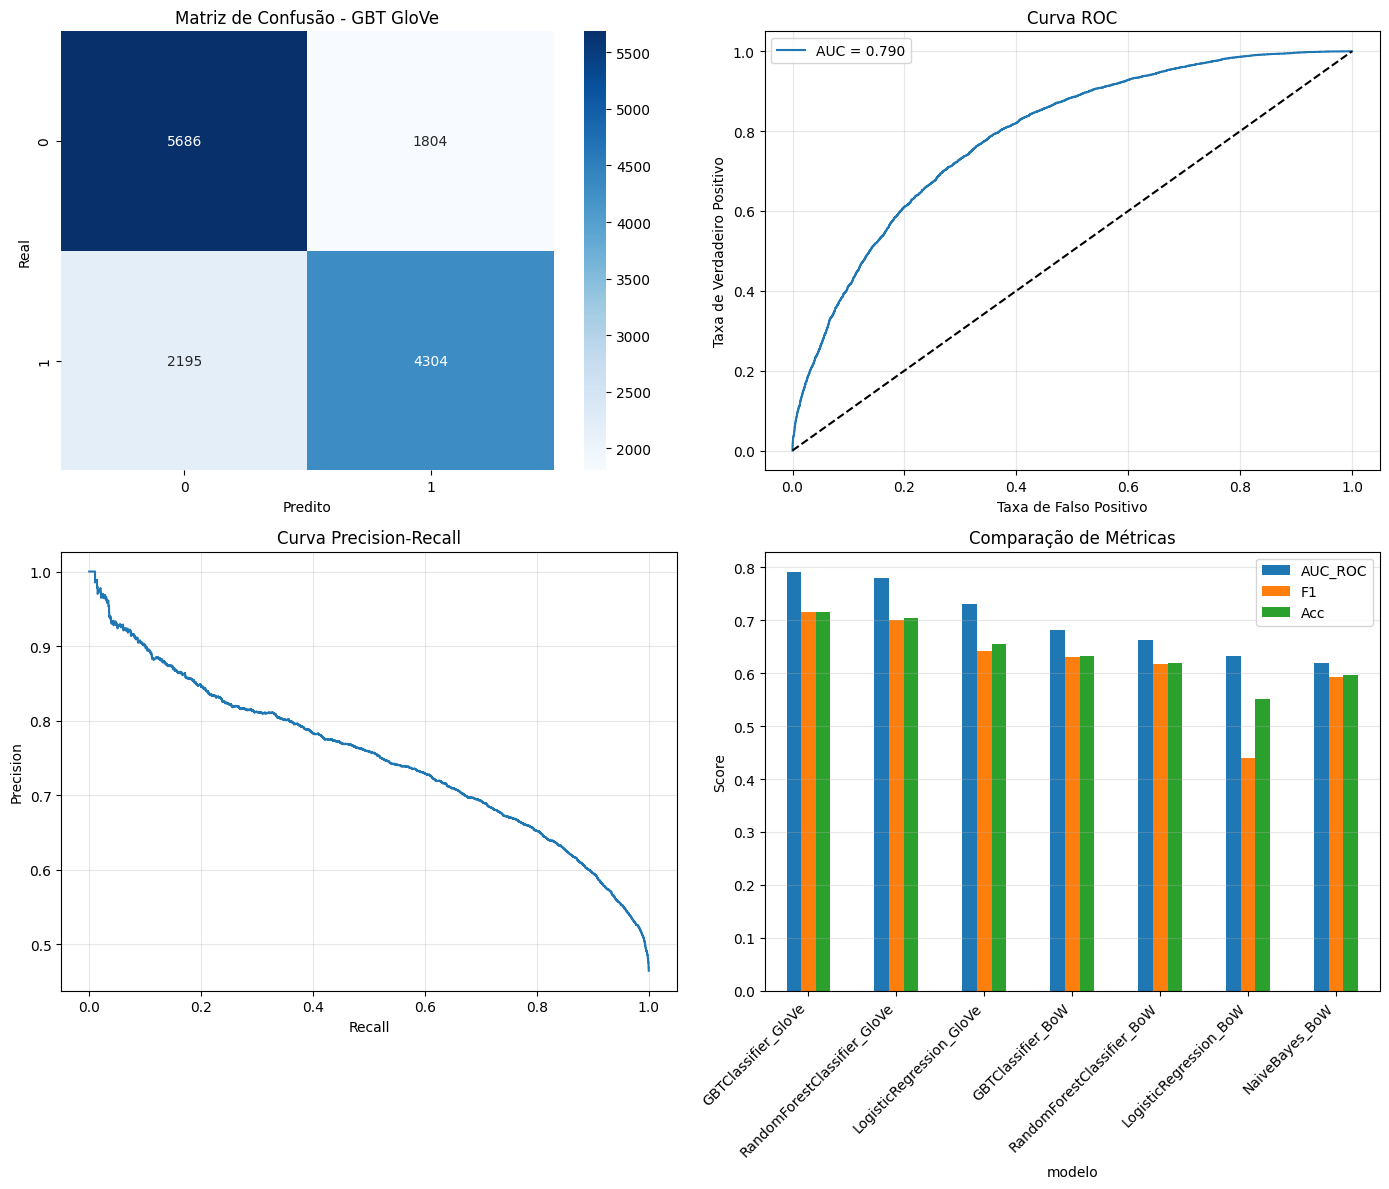

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

preds_gbt = eval_and_log(gbt_glove, "GBTClassifier_glove")
preds_gbt_pd = preds_gbt.select("label", "prediction", "probability").toPandas()
y_true = preds_gbt_pd["label"]
y_pred = preds_gbt_pd["prediction"]
y_prob = preds_gbt_pd["probability"].apply(lambda x: float(x[1]))

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Matriz de Confusão - GBT GloVe')
axes[0, 0].set_ylabel('Real')
axes[0, 0].set_xlabel('Predito')

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[0, 1].plot([0, 1], [0, 1], 'k--')
axes[0, 1].set_xlabel('Taxa de Falso Positivo')
axes[0, 1].set_ylabel('Taxa de Verdadeiro Positivo')
axes[0, 1].set_title('Curva ROC')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

precision, recall, _ = precision_recall_curve(y_true, y_prob)
axes[1, 0].plot(recall, precision)
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Curva Precision-Recall')
axes[1, 0].grid(alpha=0.3)

df_metrics.set_index('modelo')[['AUC_ROC', 'F1', 'Acc']].plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Comparação de Métricas')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

O modelo GBT (Gradient Boosted Trees) com embeddings GloVe apresentou desempenho sólido em classificação binária:

Matriz de Confusão: boa taxa de acerto para ambas as classes, embora exista número relevante de falsos negativos (2.195) e falsos positivos (1.804).

Curva ROC (AUC = 0.79): desempenho preditivo satisfatório; o modelo distingue bem as classes, embora ainda haja espaço para melhoria.

Curva Precision-Recall: comportamento decrescente suave, indicando equilíbrio entre precisão e recall, mas mostrando que a precisão cai em níveis mais altos de recall.

Comparação de Métricas: o GBT com GloVe supera os demais modelos (Random Forest, Logistic Regression, Naive Bayes) em AUC, F1 e acurácia, mostrando que combina bom ajuste e capacidade discriminativa.

Em resumo, o GBT com embeddings GloVe é o melhor modelo avaliado, equilibrando bem performance e generalização.

-----------------

### Resultados finais

In [ ]:

results_combined = [
    {
        "modelo": "GBTClassifier_GloVe",
        "AUC_ROC": 0.790542,
        "AUC_PR": 0.749126,
        "F1": 0.715629,
        "Acc": 0.716420,
        "Prec": 0.715966,
        "Rec": 0.716420
    },
    {
        "modelo": "RandomForestClassifier_GloVe",
        "AUC_ROC": 0.779631,
        "AUC_PR": 0.741481,
        "F1": 0.701174,
        "Acc": 0.704053,
        "Prec": 0.705053,
        "Rec": 0.704053
    },
    {
        "modelo": "LogisticRegression_GloVe",
        "AUC_ROC": 0.730827,
        "AUC_PR": 0.685164,
        "F1": 0.642363,
        "Acc": 0.656015,
        "Prec": 0.665976,
        "Rec": 0.656015
    },
    {
        "modelo": "GBTClassifier_BoW",
        "AUC_ROC": 0.680958,
        "AUC_PR": 0.640281,
        "F1": 0.629916,
        "Acc": 0.632923,
        "Prec": 0.631600,
        "Rec": 0.632923
    },
    {
        "modelo": "RandomForestClassifier_BoW",
        "AUC_ROC": 0.662271,
        "AUC_PR": 0.621707,
        "F1": 0.617630,
        "Acc": 0.620302,
        "Prec": 0.618677,
        "Rec": 0.620302
    },
    {
        "modelo": "LogisticRegression_BoW",
        "AUC_ROC": 0.632789,
        "AUC_PR": 0.571100,
        "F1": 0.439932,
        "Acc": 0.552144,
        "Prec": 0.587970,
        "Rec": 0.552144
    },
    {
        "modelo": "NaiveBayes_BoW",
        "AUC_ROC": 0.619843,
        "AUC_PR": 0.555618,
        "F1": 0.593411,
        "Acc": 0.597301,
        "Prec": 0.595036,
        "Rec": 0.597301
    }
]

df_metrics = pd.DataFrame(results_combined).sort_values(by="AUC_ROC", ascending=False).reset_index(drop=True)
df_metrics

,modelo,AUC_ROC,AUC_PR,F1,Acc,Prec,Rec
0,GBTClassifier_GloVe,0.790542,0.749126,0.715629,0.716420,0.715966,0.716420
1,RandomForestClassifier_GloVe,0.779631,0.741481,0.701174,0.704053,0.705053,0.704053
2,LogisticRegression_GloVe,0.730827,0.685164,0.642363,0.656015,0.665976,0.656015
3,GBTClassifier_BoW,0.680958,0.640281,0.629916,0.632923,0.631600,0.632923
4,RandomForestClassifier_BoW,0.662271,0.621707,0.617630,0.620302,0.618677,0.620302
5,LogisticRegression_BoW,0.632789,0.571100,0.439932,0.552144,0.587970,0.552144
6,NaiveBayes_BoW,0.619843,0.555618,0.593411,0.597301,0.595036,0.597301
